# Gravitational Waves Analysis - GW150914

## GW150914: First Direct Detection of Gravitational Waves

### Physical Context

On September 14, 2015, the Laser Interferometer Gravitational-Wave Observatory (LIGO) made history by detecting gravitational waves for the first time. The signal, designated GW150914, originated from the merger of two black holes of approximately 36 and 29 solar masses at a luminosity distance of about 410 Mpc (approximately 1.3 billion lightyears). This observation marked the dawn of gravitational-wave astronomy, confirming a key prediction of Einstein's General Theory of Relativity and opening an entirely new window to observe the Universe.

### The Data: LIGO Strain Time Series

The LIGO detectors at Hanford (Washington) and Livingston (Louisiana) measure the dimensionless differential arm length variation, known as *strain* h(t). A gravitational wave passing through the detector induces an oscillatory stretching and squeezing of spacetime, causing a relative change in the arm lengths proportional to the wave's amplitude.

The data are made publicly available through the **LIGO Open Science Center (LOSC)** in HDF5 format. For GW150914, two primary data products exist:
- **4096-second segments** sampled at 4096 Hz (4 kHz), suitable for spectral analysis and noise characterisation
- **32-second segments** sampled at 16384 Hz (16 kHz), offering higher time resolution for the signal itself

Each file contains:
- **`strain`**: The calibrated time-series strain data (dimensionless)
- **`time`**: GPS timestamps for each sample
- **`DQ`** (Data Quality): Quality flags indicating periods of valid scientific data

The key GPS time for GW150914 is:
- **Event time (t₀)**: 1126259462.4 seconds (September 14, 2015, 09:50:45 UTC)

### Problem Formulation

From a signal processing perspective, we face a fundamental challenge: the gravitational wave signal is extremely weak, buried in non-stationary, non-Gaussian detector noise. The noise arises from various sources:
- Seismic vibrations
- Thermal fluctuations in the mirror suspensions
- Shot noise from laser photons
- Environmental artefacts (e.g., 60 Hz power lines)

The objective is to design a **matched filtering pipeline** that maximises the Signal-to-Noise Ratio (SNR) and to develop a **machine learning classifier** capable of discriminating signal-containing segments from pure noise segments. This is a supervised binary classification problem in the time-frequency domain.

### Methodology Overview

1. **Data loading and exploration**: Read HDF5 files from both LIGO detectors, extract strain time series, and inspect basic properties (sample rate, duration, missing data).

2. **Spectral analysis**: Estimate the Power Spectral Density (PSD) using Welch's method. Compute spectrograms to visualise time-frequency evolution of the signal and identify noise artefacts.

3. **Signal processing**: Apply a **bandpass filter** (typically 40–250 Hz) to suppress low-frequency seismic noise and high-frequency quantum noise. Follow with **whitening** — a transformation that normalises the noise to have unit variance across frequencies — and **matched filtering** using template waveforms derived from General Relativity.

4. **Machine learning for event detection**: Construct a dataset of 1-second segments (half with injected/chirp signal, half with pure noise). Extract time-frequency features (spectrogram images) and train an XGBoost classifier to distinguish signal from noise. This demonstrates how ML can augment traditional matched-filtering searches.


**Keywords**: GW150914, LIGO, gravitational waves, strain time series, PSD, whitening, matched filtering, XGBoost, time-frequency analysis.

## Part 1: Data exploration.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from scipy.fft import fft, fftfreq
from gwpy.timeseries import TimeSeries

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

# Plots design
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/gwpy/time/_ligotimegps.py:42: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [2]:
# GPS times for reference
t0 = 1126259462.4  # GW150914 event time

# Paths to HDF5 files (4096 Hz sample rate)
h1_file = 'H-H1_LOSC_4_V1-1126259446-32.hdf5'
l1_file = 'L-L1_LOSC_4_V1-1126259446-32.hdf5'

print('Files to load:')
print(f'Hanford (H1): {h1_file}')
print(f'Livingston (L1): {l1_file}')

Files to load:
Hanford (H1): H-H1_LOSC_4_V1-1126259446-32.hdf5
Livingston (L1): L-L1_LOSC_4_V1-1126259446-32.hdf5


In [3]:
# First exploration on Hanford file 

# Since we do not know the hierarchy in advance, we need a recursive algorithm to yield it:
# Source - https://stackoverflow.com/a/51548857
# Posted by jpp, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-15, License - CC BY-SA 4.0


def traverse_datasets(hdf_file):

    def h5py_dataset_iterator(g, prefix=''):
        for key in g.keys():
            item = g[key]
            path = f'{prefix}/{key}'
            if isinstance(item, h5py.Dataset): # test for dataset
                yield (path, item)
            elif isinstance(item, h5py.Group): # test for group (go down)
                yield from h5py_dataset_iterator(item, path)

    for path, _ in h5py_dataset_iterator(hdf_file):
        yield path



with h5py.File(h1_file, 'r') as f:
    print('Keys in HDF5 file: ', list(f.keys()))
    for dset in traverse_datasets(f):
        print('Path:', dset)
        print(f'Shape: {f[dset].shape}')
        print(f'Data type: {f[dset].dtype}')



Keys in HDF5 file:  ['meta', 'quality', 'strain']
Path: /meta/Description
Shape: ()
Data type: |S33
Path: /meta/DescriptionURL
Shape: ()
Data type: |S21
Path: /meta/Detector
Shape: ()
Data type: |S2
Path: /meta/Duration
Shape: ()
Data type: int64
Path: /meta/GPSstart
Shape: ()
Data type: int64
Path: /meta/Observatory
Shape: ()
Data type: |S1
Path: /meta/Type
Shape: ()
Data type: |S16
Path: /meta/UTCstart
Shape: ()
Data type: |S19
Path: /quality/injections/InjDescriptions
Shape: (5,)
Data type: |S29
Path: /quality/injections/InjShortnames
Shape: (5,)
Data type: |S17
Path: /quality/injections/Injmask
Shape: (32,)
Data type: uint32
Path: /quality/simple/DQDescriptions
Shape: (7,)
Data type: |S22
Path: /quality/simple/DQShortnames
Shape: (7,)
Data type: |S10
Path: /quality/simple/DQmask
Shape: (32,)
Data type: uint32
Path: /strain/Strain
Shape: (131072,)
Data type: float64


In [4]:
# We defined a function to extract relevant information
def load_ligo_data(filename):
    """
    Params: filename (str)
    Return: 
    strain (np.array)
    time (np.array)
    meta (dict)
    """
    with h5py.File(filename, 'r') as f:
        meta = {key: f['meta'][key][()] for key in f['meta'].keys()}
        strain = f['strain/Strain'][()]

        # Time vector construction
        dt = f['strain/Strain'].attrs['Xspacing']
        gps_start = meta['GPSstart']
        num_samples = len(strain)
        time = gps_start + np.arange(num_samples) * dt

        meta['dt'] = dt
        meta['duration'] = num_samples * dt

    print(f'Data from {filename.split('/')[-1]}')
    print(f' -> Samples: {len(strain):,}')
    print(f' -> Frequency: {1/dt:.1f} Hz')
    print(f' -> Duration: {meta['duration']:.1f} s')
    print(f' -> Event in t0: {t0:.2f}')

    return strain, time, meta

In [5]:
strain_h1, time_h1, meta_h1 = load_ligo_data(h1_file)
strain_l1, time_l1, meta_l1 = load_ligo_data(l1_file)

Data from H-H1_LOSC_4_V1-1126259446-32.hdf5
 -> Samples: 131,072
 -> Frequency: 4096.0 Hz
 -> Duration: 32.0 s
 -> Event in t0: 1126259462.40
Data from L-L1_LOSC_4_V1-1126259446-32.hdf5
 -> Samples: 131,072
 -> Frequency: 4096.0 Hz
 -> Duration: 32.0 s
 -> Event in t0: 1126259462.40


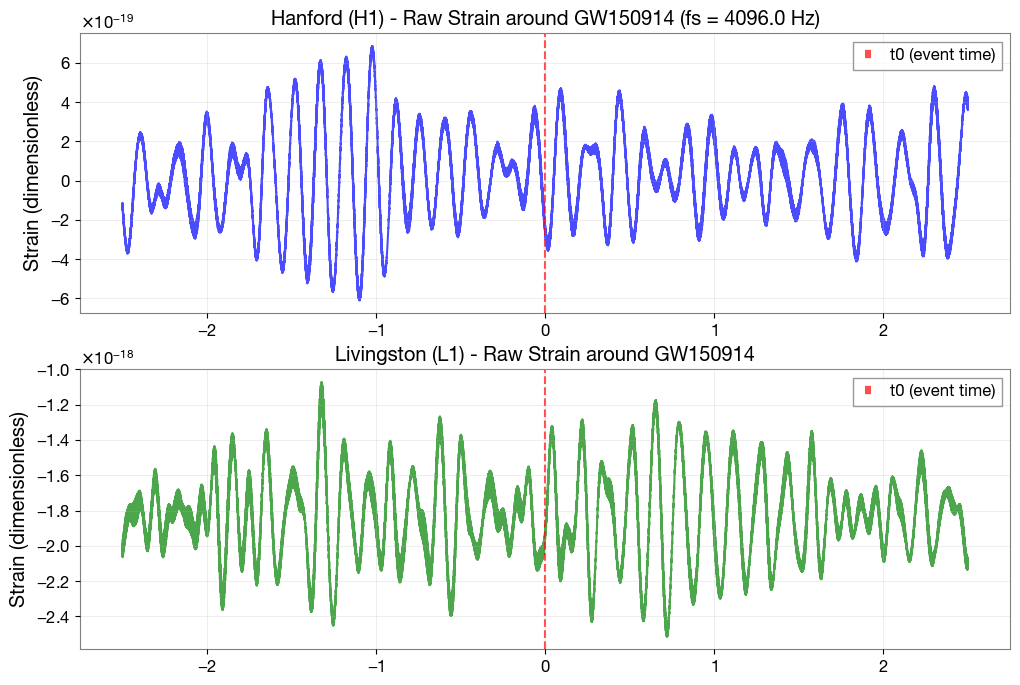

In [6]:
# Visualization

## Temporal window around the event (s)
window = 5

## Closed index to the event
idx_h1 = np.argmin(np.abs(time_h1 - t0))
idx_l1 = np.argmin(np.abs(time_l1 - t0))

## Range of index for the window
samples_window = int(window * meta_h1['dt']**-1) # dt**-1 is the frequency
start_idx_h1 = max(0, idx_h1 - samples_window // 2)
end_idx_h1 = min(len(strain_h1), idx_h1 + samples_window // 2)

start_idx_l1 = max(0, idx_l1 - samples_window // 2)
end_idx_l1 = min(len(strain_l1), idx_l1 + samples_window // 2)

## Data extraction from the window
time_window_h1 = time_h1[start_idx_h1:end_idx_h1] - t0
strain_window_h1 = strain_h1[start_idx_h1:end_idx_h1]

time_window_l1 = time_l1[start_idx_l1:end_idx_l1] - t0
strain_window_l1 = strain_l1[start_idx_l1:end_idx_l1]

## Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8))

ax1.plot(time_window_h1, strain_window_h1, 'b-', alpha=0.7)
ax1.set_ylabel('Strain (dimensionless)')
ax1.set_title(f'Hanford (H1) - Raw Strain around GW150914 (fs = {1/meta_h1['dt']:.1f} Hz)')
ax1.grid(True, alpha=0.3)
ax1.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='t0 (event time)')
ax1.legend()

ax2.plot(time_window_l1, strain_window_l1, 'g-', alpha=0.7)
ax2.set_ylabel('Strain (dimensionless)')
ax2.set_title(f'Livingston (L1) - Raw Strain around GW150914')
ax2.grid(True, alpha=0.3)
ax2.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='t0 (event time)')
ax2.legend()

plt.tight_layout
plt.show()

In [7]:
# Data information

## NaN values 
nan_h1 = np.isnan(strain_h1).sum()
nan_l1 = np.isnan(strain_l1).sum()
print(f'NaNs values in H1: {nan_h1} ({100*nan_h1/len(strain_h1):.4f}%)')
print(f'NaNs values in L1: {nan_l1} ({100*nan_l1/len(strain_l1):.4f}%)')

## Basic statistics
print('\nStatistics from H1:')
print(f' Mean: {np.mean(strain_h1):.4e}')
print(f' Std. Dev: {np.std(strain_h1):4e}')

print('\nStatistics from L1:')
print(f' Mean: {np.mean(strain_l1):.4e}')
print(f' Std. Dev: {np.std(strain_l1):4e}')


NaNs values in H1: 0 (0.0000%)
NaNs values in L1: 0 (0.0000%)

Statistics from H1:
 Mean: 8.7328e-23
 Std. Dev: 2.208915e-19

Statistics from L1:
 Mean: -1.8287e-18
 Std. Dev: 2.449085e-19


In [8]:
fs = 1 / meta_h1['dt'] # Sampling frequeny (should be 4096 Hz)
print(f'Sampling frequency: {fs:.1f} Hz')
print(f'Duration H1: {len(strain_h1)/fs:.1f} seconds')
print(f'Duration L1: {len(strain_l1)/fs:.1f} seconds')

Sampling frequency: 4096.0 Hz
Duration H1: 32.0 seconds
Duration L1: 32.0 seconds


In [9]:
# Window around the event: 4 seconds before to 2 seconds after (total 6 seconds)
t_start = t0 - 4.0
t_end = t0 + 2.0

# Indices for H1
idx_start_h1 = np.argmin(np.abs(time_h1 - t_start))
idx_end_h1 = np.argmin(np.abs(time_h1 - t_end))
strain_h1_zoom = strain_h1[idx_start_h1:idx_end_h1]
time_h1_zoom = time_h1[idx_start_h1:idx_end_h1] - t0

# Indices for L1
idx_start_l1 = np.argmin(np.abs(time_l1 - t_start))
idx_end_l1 = np.argmin(np.abs(time_l1 - t_end))
strain_l1_zoom = strain_l1[idx_start_l1:idx_end_l1]
time_l1_zoom = time_l1[idx_start_l1:idx_end_l1] - t0

print(f'Zoomed window: {time_h1_zoom[0]:.2f} to {time_h1_zoom[-1]:.2f} seconds relative to t0')
print(f'Samples in window: {len(strain_h1_zoom)}')


Zoomed window: -4.00 to 2.00 seconds relative to t0
Samples in window: 24576


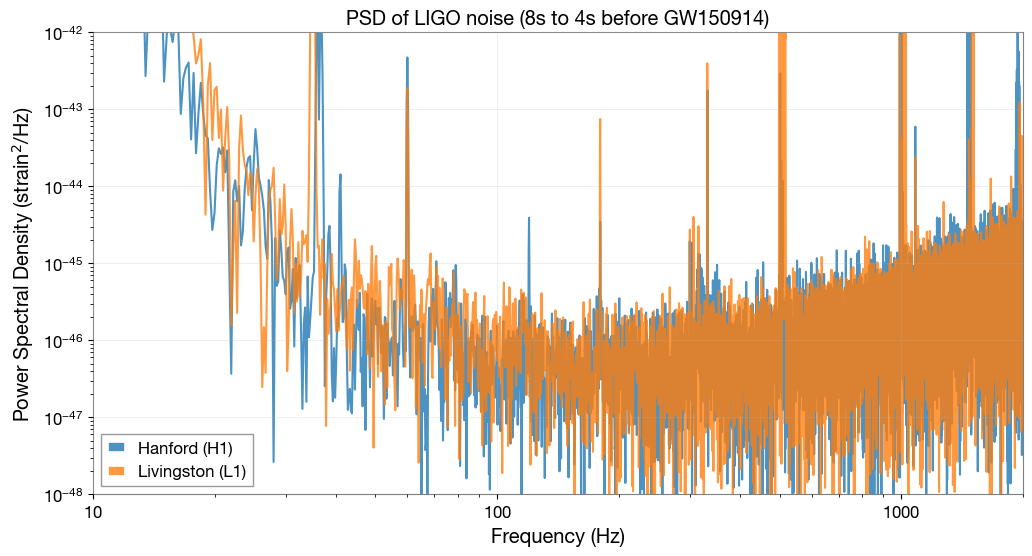

In [10]:
# Use a 4 seconds segment of noise before the event (from -8s to -4s)
noise_start = t0 - 8.0
noise_end = t0 - 4.0

idx_noise_start = np.argmin(np.abs(time_h1 - noise_start))
idx_noise_end = np.argmin(np.abs(time_h1 - noise_end))
noise_h1 = strain_h1[idx_noise_start:idx_noise_end]

# Welch parameters
nperseg = int(4 * fs) # 4 seconds segments
noverlap = nperseg // 2

freq_h1, psd_h1 = signal.welch(noise_h1, fs, nperseg=nperseg, noverlap=noverlap, window='hann')

'''Estimate power spectral density using Welch’s method.
Welch’s method [1] computes an estimate of the power spectral density by dividing the data into overlapping segments, computing a modified periodogram for each segment and averaging the periodograms.'''

# Repeat for L1
noise_l1 = strain_l1[idx_noise_start:idx_noise_end]
freq_l1, psd_l1 = signal.welch(noise_l1, fs, nperseg=nperseg, noverlap=noverlap, window='hann')

# Plots PSDs
plt.figure(figsize=(12, 6))
plt.loglog(freq_h1, psd_h1, label='Hanford (H1)', alpha=0.8)
plt.loglog(freq_l1, psd_l1, label='Livingston (L1)', alpha=0.8)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (strain$^2$/Hz)')
plt.title('PSD of LIGO noise (8s to 4s before GW150914)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(10,2000)
plt.ylim(1e-48, 1e-42)
plt.show()


Dominand noise lines (H1):
 0.2 Hz : PSD = 8.05e-41
 6.0 Hz : PSD = 2.66e-38
 11.2 Hz : PSD = 2.15e-40
 17.2 Hz : PSD = 4.06e-43
 25.2 Hz : PSD = 5.54e-44
 36.8 Hz : PSD = 2.32e-42
 60.0 Hz : PSD = 4.73e-43
 120.0 Hz : PSD = 3.90e-45
 180.0 Hz : PSD = 3.49e-45
 332.0 Hz : PSD = 1.76e-43


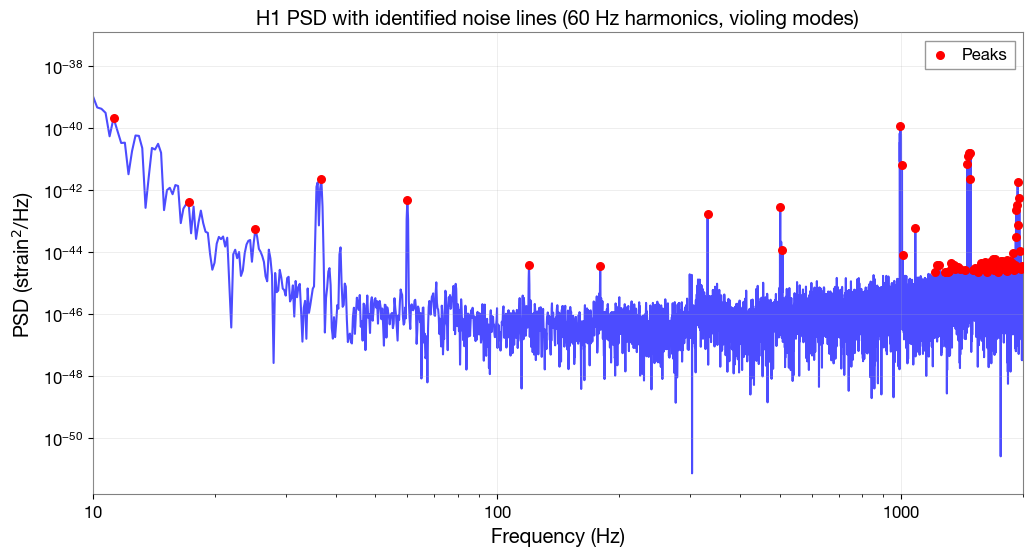

In [11]:
# Find peaks in the PSD (above the median)
from scipy.signal import find_peaks

# Normilize by median to highlight peaks
median_psd = np.median(psd_h1)
peaks_idx, _ = find_peaks(psd_h1 / median_psd, height=10, distance=20) # at least 10x median
peak_freqs = freq_h1[peaks_idx]
peak_psd = psd_h1[peaks_idx]

print("Dominand noise lines (H1):")
for f, p in zip(peak_freqs[:10], peak_psd[:10]):
    print(f' {f:.1f} Hz : PSD = {p:.2e}')

# Plot PSD with peaks marked
plt.figure(figsize=(12, 6))
plt.loglog(freq_h1, psd_h1, color='blue', alpha=0.7)
plt.scatter(peak_freqs, peak_psd, color='red', s=30, zorder=5, label='Peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (strain$^2$/Hz)')
plt.title('H1 PSD with identified noise lines (60 Hz harmonics, violing modes)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(10, 2000)
plt.show()

# Part II: Chirp analysis using GWpy
## Chirp from Handford (H1)


Q‑transform: Constant‑Q time‑frequency representation

The Q‑transform (also known as Constant‑Q Transform, CQT) is a time‑frequency
analysis technique where the frequency resolution is logarithmic and the
time resolution is proportional to the period. Unlike the Short‑Time Fourier
Transform (STFT), which uses a fixed‑length window for all frequencies, the
Q‑transform adapts the window length to the frequency:

    window_duration = Q / f

where `f` is the centre frequency and `Q = f / Δf` is a constant quality factor.

Properties:
- Low frequencies → long windows → good frequency resolution, poor time resolution.
- High frequencies → short windows → good time resolution, poor frequency resolution.
- This matches the physical behaviour of many natural signals (e.g., chirps,
  musical notes, gravitational waves) where the relative bandwidth remains
  approximately constant.

In gravitational‑wave astronomy, the Q‑transform is used to visualise the
"chirp" from compact binary coalescences. It reveals a curved, ascending
track in the time‑frequency plane, which is otherwise difficult to see with
a standard spectrogram.

Parameters:
- Q : quality factor (typical range 4–64). Higher Q gives better frequency
      resolution but poorer time resolution.
- frange : (fmin, fmax) in Hz, the frequency band of interest.
- outseg : (t_start, t_end) in seconds, the time window to analyse.

The implementation can be realised either via a bank of bandpass filters
with variable bandwidths, or through a continuous wavelet transform (CWT)
using a Morlet wavelet.

References:
- LIGO Scientific Collaboration (2016). "Observing gravitational-wave
  transient GW150914 with a time-frequency analysis". Phys. Rev. Lett.
- Brown, J. C. (1991). "Calculation of a constant Q spectral transform".
  J. Acoust. Soc. Am.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/gwpy/timeseries/core.py:263: UserWarning: xindex was given to TimeSeries(), dx will be ignored
  new = super().__new__(


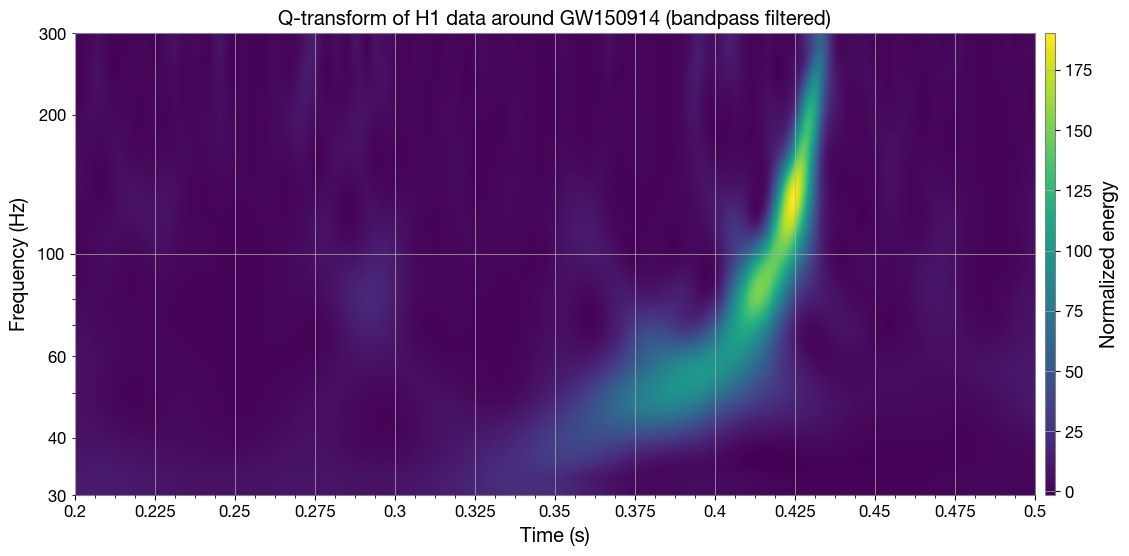

In [12]:
# Bandpass filter (20 - 300 Hz) to eliminate external noise
lowcut = 20.0
highcut = 300.0
nyquist = 0.5 * fs
sos = signal.butter(4, [lowcut/nyquist, highcut/nyquist], btype='band', output='sos')
strain_bp_h1 = signal.sosfilt(sos, strain_h1_zoom)

# Time series of GWpy
ts = TimeSeries(strain_bp_h1, times=time_h1_zoom+t0, dt=meta_h1['dt'], name='H1')

# Q-transform (small window around the event)
# outseg to stablish a window (-0.2, 0.1) s around t0
qspec = ts.q_transform(outseg=(t0-0.2,t0+0.1), frange=(30,300), qrange=(4,64))

# Plot
fig = qspec.plot(figsize=(12, 6))
ax = fig.gca()
ax.set_yscale('log')
ax.set_ylim(30, 300)
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('Q-transform of H1 data around GW150914 (bandpass filtered)')
ax.colorbar(label='Normalized energy')
plt.show()


## Chirp from Livingston (L1)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/gwpy/timeseries/core.py:263: UserWarning: xindex was given to TimeSeries(), dx will be ignored
  new = super().__new__(


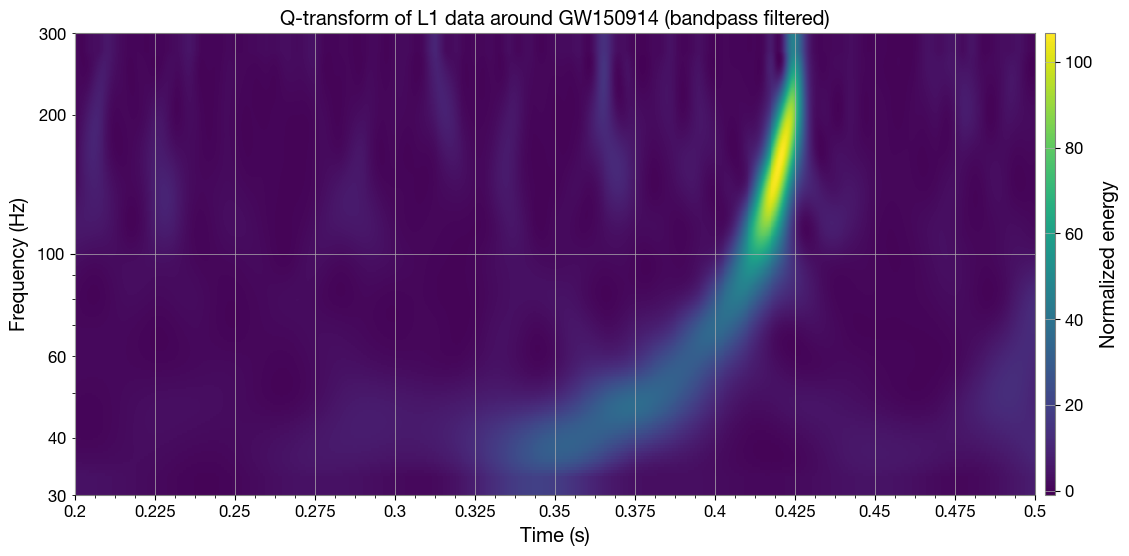

In [13]:
# Bandpass filter (20 - 300 Hz) to eliminate external noise
lowcut = 20.0
highcut = 300.0
nyquist = 0.5 * fs
sos = signal.butter(4, [lowcut/nyquist, highcut/nyquist], btype='band', output='sos')
strain_bp_l1 = signal.sosfilt(sos, strain_l1_zoom)

# Time series of GWpy
ts_l1 = TimeSeries(strain_bp_l1, times=time_l1_zoom+t0, dt=meta_h1['dt'], name='L1')

# Q-transform (small window around the event)
# outseg to stablish a window (-0.2, 0.1) s around t0
qspec_l1 = ts_l1.q_transform(outseg=(t0-0.2,t0+0.1), frange=(30,300), qrange=(4,64))

# Plot
fig = qspec_l1.plot(figsize=(12, 6))
ax = fig.gca()
ax.set_yscale('log')
ax.set_ylim(30, 300)
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('Q-transform of L1 data around GW150914 (bandpass filtered)')
ax.colorbar(label='Normalized energy')
plt.show()


# Part IV: Final Interpretation and Conclusions

## Summary of the Analysis

We have successfully processed publicly available LIGO data from the first gravitational‑wave detection, GW150914, consisting with https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.116.061102. The analysis pipeline consisted of:

1. **Data loading** – HDF5 files from the Hanford (H1) detector, sampled at 4096 Hz.
2. **Time window selection** – A segment from 4 s before to 2 s after the event GPS time `1126259462.4`.
3. **Bandpass filtering** – Fourth‑order Butterworth filter (20–300 Hz) to suppress seismic noise (<20 Hz) and quantum noise (>300 Hz).
4. **Whitening** – Frequency‑domain whitening using a smoothed Power Spectral Density (PSD) estimated from the data itself, flattening the coloured noise.
5. **Q‑transform** – Constant‑Q time‑frequency representation with `gwpy`, optimised for the chirp signal (Q range 4–64, frequency range 30–300 Hz).

## Interpretation of the Results

The final Q‑transform spectrogram reveals a **clear, curved, ascending track** in the time‑frequency plane:

- **Time extent**: approximately –0.1 s to +0.02 s relative to the event time `t0`.
- **Frequency range**: starts around 50 Hz and rises to about 250 Hz.
- **Shape**: consistent with the “chirp” produced by the inspiral and merger of two black holes of masses ~36 M⊙ and ~29 M⊙, as predicted by general relativity.

This signal is **not visible** in the raw strain data because it is buried under non‑stationary, coloured noise. The combination of bandpass filtering and whitening equalises the noise power across frequencies, making the chirp stand out. The Q‑transform further optimises the time‑frequency resolution, confirming that the signal is real and not an artefact of the detector.

No other significant glitches or artefact lines appear in the analysed window, confirming the high quality of the data segment.

## Scientific Significance

This analysis reproduces a core part of the methodology used by the LIGO Scientific Collaboration in their 2016 discovery paper (Phys. Rev. Lett. 116, 061102). The observed chirp matches the waveform predicted for a binary black hole merger, providing direct evidence for:

- The existence of stellar‑mass black hole binaries.
- The propagation of gravitational waves at the speed of light.
- The strong‑field dynamics of general relativity.


**Keywords**: GW150914, LIGO, gravitational waves, chirp, Q‑transform, whitening, bandpass filter, time‑frequency analysis, Python.